## Statistical Analysis on the model

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18
import numpy as np
import matplotlib.pyplot as plt
import mat73
import scipy.signal as ss
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
from scipy import signal

### Firing rate from data

In [2]:
def compute_fr_v(data, mean_interspike_time, coef):
    ev = data
    T = int(mean_interspike_time * coef)

    cumsum = np.cumsum(np.insert(ev, 0, 0))
    density = (cumsum[T:] - cumsum[:-T]) / T
    density = np.concatenate([density, np.zeros(T-1)])

    return density


In [6]:
pwd

'D:\\new_data_thalamus'

In [3]:
cd D:

D:\


In [4]:
cd new_data_thalamus/

D:\new_data_thalamus


In [3]:
import matplotlib.pyplot as plt


In [8]:
import os 
os.listdir()

['Piezo_220131_114858.mat',
 'Piezo_220210_110252.mat',
 'Piezo_220211_114822.mat']

In [5]:
from scipy.signal import find_peaks


def Thres(coef,x):
    """
    Calculates Quiroga detection threshold
    """
    return coef*np.median(np.abs(x)/0.6745)


def peak_value(sig, thres,dist = 1):
    """
    Finds peaks in a time series.
    Set eventual other constraints in the scipy.signal function find_peaks
    """
    sig2 = np.zeros(sig.shape, dtype = int)

    p2 = find_peaks(sig, height = thres, distance = dist)
    #print(p2)
    p2 = p2[0]

    return max(sig[np.array(p2.tolist())])



In [6]:
import sys
sys.path.append("C:/Users/Benedetta/Desktop/Criticality in barrel cortex/Codes/Marianietal2026-PlosCompBio/Modules")

In [7]:
from functions import *

In [8]:

import os
import numpy as np
import scipy.signal as ss
import mat73
start = 0
notchfilter = 1
for rat in [1]:
    thalamus = 1

    for file in [os.listdir()[start:][rat]]:
        if file == 'Figs': continue
        print(os.getcwd(), file)
        data_dict = mat73.loadmat(file)
        data = data_dict['amplifier_data']
        if thalamus: stim = data_dict['adc_data'][0]
        if not thalamus: stim = data_dict['adc_data']
        indexes = (np.where(stim> 1.5)[0])[np.where(np.diff(np.where(stim> 1.5)[0])>1)]
        indexes = np.array(indexes.tolist() + [int(indexes[-1] + np.diff(indexes)[-1])]) - 125
        fs = 25000
        conv = 1/fs
        nyq = 0.5*fs
        low = 0.1/nyq
        high = 150/nyq
        b,a = ss.butter(2,[low,high], "bandpass")
        sig = ss.filtfilt(b,a,data,axis = 1,)
        if notchfilter:
            fs = 25000.0  # Sample frequency (Hz)
            f0 = 100.0  # Frequency to be removed from signal (Hz)
            Q = 30.0  # Quality factor
            # Design notch filter
            b, a = ss.iirnotch(f0, Q, fs)
            sig2 =  ss.filtfilt(b,a,sig,axis = 1)
        else:
            sig2 = sig
        nyq = 0.5*fs
        low = 300/nyq
        high = 3000/nyq
        b,a = ss.butter(2,high, "lowpass")
        sk = ss.filtfilt(b,a,data,axis = 1,)
        b,a = ss.butter(2,low, "highpass")
        spikes = ss.filtfilt(b,a,sk,axis = 1)
        det = (spikes - np.mean(spikes,0))
        del spikes, sig

        lfpTrials = []
        for r in range(1,len(indexes)-1):
            lfpTrials.append(sig2[:30,indexes[r]-25000:indexes[r]+ int(25000)*10])
        lfpTrials = np.array(lfpTrials)
        spikesTrials = []
        for r in range(1,len(indexes)-1):
            spikesTrials.append(det[:30,indexes[r]-25000:indexes[r] + 25000*10])
        spikesTrials = np.array(spikesTrials)


        num = spikesTrials.shape[0]
        soglia = 4
        binspikes =  np.zeros((num,int(25000)*11,spikesTrials.shape[1]))
        for i in range(num):
            for ch in range(spikesTrials.shape[1]):
                binspikes[i,:,ch] = findpeaks(spikesTrials[i,ch,:], Thres(soglia,spikesTrials[i,ch,:]),"neg", dist = 10)

D:\new_data_thalamus Piezo_220210_110252.mat


In [10]:
timebin = 500
#lagg = []
coef = 3
total_f = np.zeros((binspikes.shape[0],binspikes.shape[2],binspikes.shape[1]))
nTrials = binspikes.shape[0]
nch = binspikes.shape[2]

for g in range(nTrials):
    for n in range(nch):
        f= compute_fr_v(binspikes[g,:,n], 500,3)
        #plt.plot(f)
        total_f[g,n] = f

### Model

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [30]:

plt.rcParams['text.usetex'] =True
plt.rcParams['font.family'] = 'serif',
plt.rcParams['font.serif'] =  'Computer Modern'

In [31]:
from scipy.special import erf

def ModelOscillWilsonBook(t_final,dt,x_0,proc):

    def Acti(V,theta, rho, Tx):
        return (1 + erf((V -(theta - rho))/Tx))/2
    
    ec = 42
    ic = 12
    tce = 12
    tci = 10
    taue = 5
    taui = 15
    
    wee = 1
    wei = 1
    
    wie = 2
    wii = 1.5
    
    wte = 3.9
    wti = 1.5## original 6
    gamma_e = 5
    gamma_i = 15
    
    er = 2.2## original 7.4
    ir = 4.1
    
    Te = 12.03
    Ti = 11.62
    rho = -60
    theta = -45
    
    
    S0 =np.random.random(2)*x_0
    
    T = t_final
    N = int(T/dt)
  
    S = np.zeros((2,N))
    P = np.zeros(N)
    S[:,0] = S0
    for r in range(N-1):
        P[r] = gamma_e*(1-er*Acti(S[0,r],theta,rho,Te))*Acti(wee*ec*S[0,r]+ wte*tce*(proc[r])-wie*ic*S[1,r],theta,rho,Te)
        S[0,r+1] = S[0,r] +(-S[0,r] + P[r])*dt/taue
        S[1,r+1] = S[1,r] +(-S[1,r] + gamma_i*(1-ir*Acti(S[1,r],theta,rho,Ti))*Acti(wei*ec*S[0,r]+ wti*tci*(proc[r])-wii*ic*S[1,r],theta,rho,Ti))*dt/taui
    P[-1] = gamma_e*(1-er*Acti(S[0,-1],theta,rho,Te))*Acti(wee*ec*S[0,-1]+ wte*tce*(proc[-1])-wie*ic*S[1,-1],theta,rho,Te)
    #P[-1] = 
    return S, P

(28, 30, 275000)

### Model evoked activity

In [32]:
import emd
from mpl_toolkits.axes_grid1 import make_axes_locatable
final = []
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


T = 1000*2
sample_rate = 25000
taue = 5
dt = 0.04
N = int(T/dt)
times = np.arange(0,T,0.04)
times = times*1e-3

for trial in range(total_f.shape[0]):

    mean_ch = np.mean(total_f[trial,6:12,25000:25000*3], 0)*25 # in ms
    


    sigma_samples = 100 # ad esempio 5 campioni
    smoothed = gaussian_filter1d(mean_ch, sigma=sigma_samples)
    
    psth = smoothed/np.max(smoothed)*0.3
    proc = np.zeros(N)

    for g in range(N-1):
        proc[g+1] = proc[g] +(-proc[g]*dt + psth[g]*dt)/taue

    print(times[-1])
    S = ModelOscillWilsonBook(T,dt,2,proc)
    ii = 35

    x = S[0][0]
    imf2 = emd.sift.mask_sift(x, mask_freqs =ii/sample_rate)
    IP, IF, IA = emd.spectra.frequency_transform(imf2, sample_rate, 'nht')
    freq_range = (0, 45, 64)

    hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)

    final.append(spec)

    

1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002
1.9999600000000002


In [35]:
final = np.asarray(final)


### Model spontaneous acitivity

In [38]:
import emd
from mpl_toolkits.axes_grid1 import make_axes_locatable
final_rest = []

from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


T = 1000*7
sample_rate = 25000
taue = 5
dt = 0.04
N = int(T/dt)
times = np.arange(0,T,0.04)
times = times*1e-3

for trial in range(total_f.shape[0]):

    mean_ch = np.mean(total_f[trial,6:12,25000*4:], 0)*25 # in ms
    mean_ch_st = np.mean(total_f[trial,6:12,12500:25000*3], 0)*25 # in ms
    sigma_samples = 100 
    smoothed = gaussian_filter1d(mean_ch, sigma=sigma_samples)

    sigma_samples = 100 
    smoothed_st = gaussian_filter1d(mean_ch_st, sigma=sigma_samples)
    
    psth = smoothed/np.max(smoothed_st)*0.3
        
    proc = np.zeros(N)

    for g in range(N-1):
        proc[g+1] = proc[g] +(-proc[g]*dt + psth[g]*dt)/taue

    print(times[-1])
    S = ModelOscillWilsonBook(T,dt,2,proc)
    ii = 35

 
    x = S[0][0]
    imf2 = emd.sift.mask_sift(x, mask_freqs =ii/sample_rate)
    IP, IF, IA = emd.spectra.frequency_transform(imf2, sample_rate, 'nht')
    freq_range = (0, 45, 64)

    hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density', sum_imfs=False)

    final_rest.append(spec)



6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001
6.999960000000001


In [39]:
final_rest = np.asarray(final_rest)
print(final_rest.shape)
final = np.asarray(final)
final.shape

(28, 64, 9)


(28, 64, 7)

In [40]:
final = np.asarray(final)
peaks_stim_1 = []
for i in range(final.shape[0]):
    v = peak_value(final[i,:,1],0.5*np.std(final[i,:,1]))
    
    peaks_stim_1.append(v)
    
    
peaks_stim_3 = []
for i in range(final.shape[0]):
    v = peak_value(final[i,:,3],0.5*np.std(final[i,:,3]))
    
    peaks_stim_3.append(v)

In [41]:
final_rest = np.asarray(final_rest)

peaks_rest_1 = []
for i in range(final.shape[0]):
    v = peak_value(final_rest[i,:,1],0.5*np.std(final_rest[i,:,1]))
    
    peaks_rest_1.append(v)
    
    
peaks_rest_3 = []
for i in range(final.shape[0]):
    v = peak_value(final_rest[i,:,3],0.5*np.std(final_rest[i,:,3]))
    
    peaks_rest_3.append(v)
    

10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002
10.999960000000002


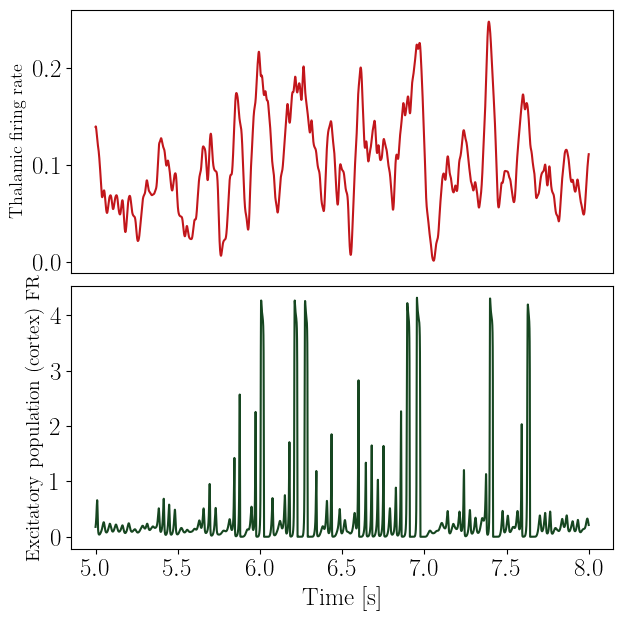

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
colors = cm.Reds(np.linspace(0,1,10))

import emd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


T = 1000*11
sample_rate = 25000
taue = 5
dt = 0.04
N = int(T/dt)
times = np.arange(0,T,0.04)
times = times*1e-3

for trial in range(total_f.shape[0]):

    mean_ch = np.mean(total_f[trial,6:12,:], 0)*25 # in ms
    sigma_samples = 100 # ad esempio 5 campioni
    smoothed = gaussian_filter1d(mean_ch, sigma=sigma_samples)
    psth = smoothed/np.max(smoothed)*0.3
    proc = np.zeros(N)
    for g in range(N-1):
        proc[g+1] = proc[g] +(-proc[g]*dt + psth[g]*dt)/taue

    print(times[-1])
    S = ModelOscillWilsonBook(T,dt,2,proc)
    if trial ==13: break




x = np.arange(0,25000*11,1)/25000-1
x = x[25000*6:25000*9]
y1 = proc[25000*6:25000*9]        
y2 = S[1][25000*6:25000*9]     
#fig = plt.subplots(figsize=(10,6))

fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,                 
    figsize=(7, 7),

    gridspec_kw={
        'height_ratios': [1, 1]   #
    }
)


ax_top.plot(x, y1, color = colors[7])
ax_top.set_ylabel("Thalamic firing rate", fontsize =13)
ax_top.set_xticks([])

ax_bottom.plot(x, y2, color="#164620")
ax_bottom.set_ylabel("Excitatory population (cortex) FR", fontsize = 14)

ax_bottom.set_xlabel("Time [s]")
#ax_bottom.legend(loc=(.65,0.85), fontsize=11,framealpha=1)
plt.subplots_adjust(hspace=0.05)
#plt.show()
#plt.savefig(path_figs + 'Spont_Act.jpg', dpi = 300, bbox_inches='tight');

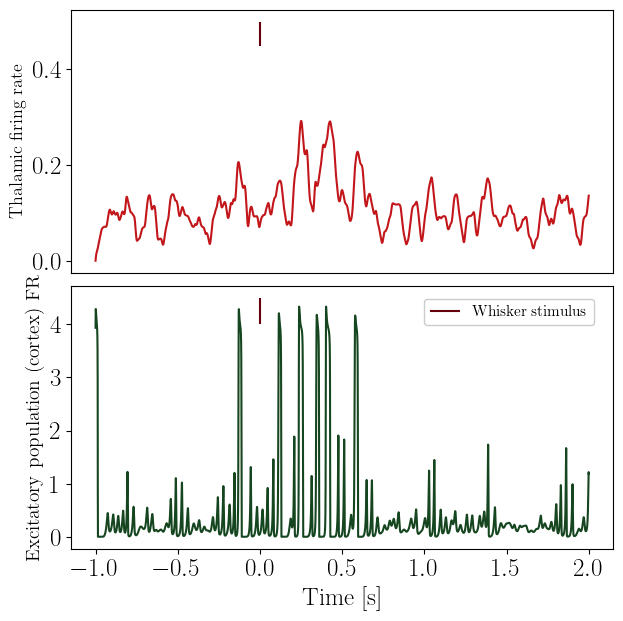

In [47]:
import matplotlib.pyplot as plt
import numpy as np


x = np.arange(0,25000*11,1)/25000-1
x = x[:25000*3]
y1 = proc[:25000*3]      
y2 = S[1][:25000*3]     


fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,                 # 2 righe, 1 colonna
    figsize=(7, 7),

    gridspec_kw={
        'height_ratios': [1, 1]   
    }
)


ax_top.plot(x, y1, color = colors[7])
ax_top.set_ylabel("Thalamic firing rate", fontsize =13)
ax_top.set_xticks([])
ax_top.vlines(0,0.45,0.5,color=colors[9])


ax_bottom.plot(x, y2, color="#164620")
ax_bottom.set_ylabel("Excitatory population (cortex) FR", fontsize = 14)

ax_bottom.vlines(0,4,4.5,color=colors[9], label='Whisker stimulus')


ax_bottom.set_xlabel("Time [s]")
ax_bottom.legend(loc=(.65,0.85), fontsize=11,framealpha=1)
plt.subplots_adjust(hspace=0.05)
#plt.show()
#plt.savefig(path_figs + 'Evoked_Act.jpg', dpi = 300, bbox_inches='tight');


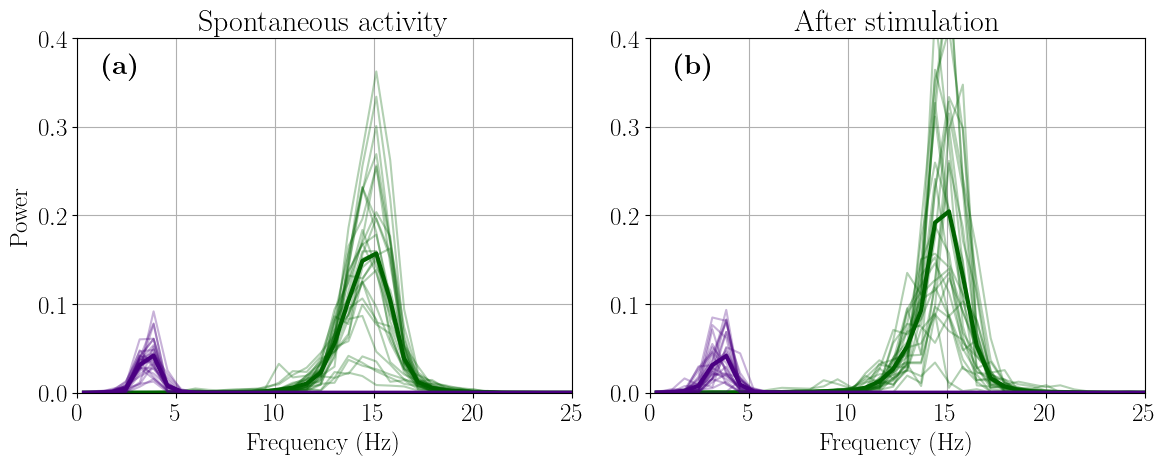

In [42]:
import emd
from mpl_toolkits.axes_grid1 import make_axes_locatable
ii = 35
fig = plt.figure(figsize =(12,5))

gs = fig.add_gridspec(1,2,width_ratios = [1,1],
                      height_ratios = [1])

ax01 = fig.add_subplot(gs[0,1])


ax01.plot(hht_f,final[:,:,1].T, color = 'darkgreen', alpha = 0.3);
ax01.plot(hht_f,np.mean(final[:,:,1],0), color = 'darkgreen', lw = 3);
ax01.plot(hht_f,final[:,:,3].T, color = 'indigo', alpha = 0.3)
#plt.title('Spontaneous activity')
ax01.plot(hht_f,np.mean(final[:,:,3],0), color = 'indigo', lw = 3);



ax02 = fig.add_subplot(gs[0,0])
ax02.plot(hht_f,final_rest[:,:,1].T, color = 'darkgreen', alpha = 0.3);
ax02.plot(hht_f,np.mean(final_rest[:,:,1],0), color = 'darkgreen', lw=3);


ax02.plot(hht_f,final_rest[:,:,3].T, color = 'indigo', alpha = 0.3);
ax02.plot(hht_f,np.mean(final_rest[:,:,3],0), color = 'indigo', lw = 3);


ax02.grid(True)
ax01.grid(True)
ax02.set_title('Spontaneous activity')
ax01.set_title('After stimulation')

ax02.set_xlim(0, 25)
ax01.set_xlim(0, 25)


ax02.set_ylim(0, 0.4)
ax01.set_ylim(0, 0.4)


ax02.set_xlabel('Frequency (Hz)');
ax01.set_xlabel('Frequency (Hz)');

ax02.set_ylabel(f'Power');

ax = np.asarray([ax01,ax02])
ax = ax[np.newaxis,:]


ax[0,0].annotate('\\textbf{(b)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05, 0.9), textcoords='axes fraction')

ax[0,1].annotate('\\textbf{(a)}', size = 20,
                 xy=(1, 1), xycoords='axes fraction',
                 xytext=(0.05,0.9), textcoords='axes fraction')



plt.tight_layout();
#plt.savefig("../../../Desktop/Criticality in barrel cortex/Thalamus/Paper Figures/Figure 4-2.png", bbox_inches = 'tight' )
#plt.ylim(0,0.1)

### Statistical Tests

In [43]:
from scipy import stats
stats.ttest_rel(peaks_stim_1, peaks_rest_1,alternative ='greater')

TtestResult(statistic=3.3111579851724735, pvalue=0.0013224776505625277, df=27)

In [44]:
stats.ttest_rel(peaks_stim_3, peaks_rest_3,alternative ='greater')


TtestResult(statistic=0.964178763191853, pvalue=0.17175658828517665, df=27)